# 🎮 Phân Tích Xu Hướng Thị Trường Trò Chơi Điện Tử & Dự Đoán Doanh Số Bán Hàng Toàn Cầu

**Sinh viên:** Nguyễn Như Khiêm — **MSSV:** K225480106030  
**Môn học:** Khoa Học Dữ Liệu  
**GVHD:** TS. Nguyễn Văn Huy

---

## Mục tiêu
1. Phân tích xu hướng thị trường game theo thể loại, nền tảng, nhà phát hành, khu vực và thời gian
2. Xây dựng mô hình **Hồi quy** dự đoán doanh số toàn cầu
3. **Phân cụm** nhóm các trò chơi có đặc điểm doanh số tương đồng

In [15]:
# ============================================================
# 0. IMPORT THƯ VIỆN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Style toàn cục
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

# Bảng màu chính
PALETTE = ['#2D6A9F', '#E8543A', '#3DAA6E', '#F5A623', '#9B59B6',
           '#1ABC9C', '#E74C3C', '#F39C12', '#27AE60', '#8E44AD']

print('✅ Thư viện đã sẵn sàng!')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  sklearn OK')

✅ Thư viện đã sẵn sàng!
  pandas  2.3.3
  numpy   2.4.2
  sklearn OK


In [31]:
# ============================================================
# 1. TẢI VÀ KHÁM PHÁ DỮ LIỆU
# ============================================================
df = pd.read_csv('video_games_sales.csv')

print('='*55)
print('  THÔNG TIN BỘ DỮ LIỆU VIDEO GAME SALES')
print('='*55)
print(f'  Số lượng game   : {len(df):,}')
print(f'  Số cột          : {df.shape[1]}')
print(f'  Khoảng năm      : {int(df["Year"].min())} – {int(df["Year"].max())}')
print(f'  Số Platform     : {df["Platform"].nunique()}')
print(f'  Số thể loại     : {df["Genre"].nunique()}')
print(f'  Số nhà phát hành: {df["Publisher"].nunique()}')
print('='*55)
df.head(10)

# Kiểm tra missing values & thống kê
print('--- Missing Values ---')
print(df.isnull().sum())
print()

# Làm sạch
df.dropna(subset=['Year', 'Genre', 'Publisher'], inplace=True)
df['Year'] = df['Year'].astype(int)

# thông tin bộ dữ liệu sau khi làm sạch
print('--- Thông tin bộ dữ liệu sau khi làm sạch ---')
print(f'  Số lượng game   : {len(df):,}')
print(f'  Số nhà phát hành: {df["Publisher"].nunique()}')

# print('--- Thống Kê Mô Tả ---')
# df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].describe().round(2)

  THÔNG TIN BỘ DỮ LIỆU VIDEO GAME SALES
  Số lượng game   : 16,598
  Số cột          : 11
  Khoảng năm      : 1980 – 2020
  Số Platform     : 31
  Số thể loại     : 12
  Số nhà phát hành: 578
--- Missing Values ---
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

--- Thông tin bộ dữ liệu sau khi làm sạch ---
  Số lượng game   : 16,291
  Số nhà phát hành: 576


---
## 📊 CÂU HỎI 1 — Thể loại game có doanh số cao nhất


================ TỔNG DOANH SỐ THEO THỂ LOẠI ================

    Thể loại  Tổng doanh số (triệu USD)
      Action                    1722.84
      Sports                    1309.24
     Shooter                    1026.20
Role-Playing                     923.83
    Platform                     829.13
        Misc                     789.87
      Racing                     726.76
    Fighting                     444.05
  Simulation                     389.98
      Puzzle                     242.21
   Adventure                     234.59
    Strategy                     173.27


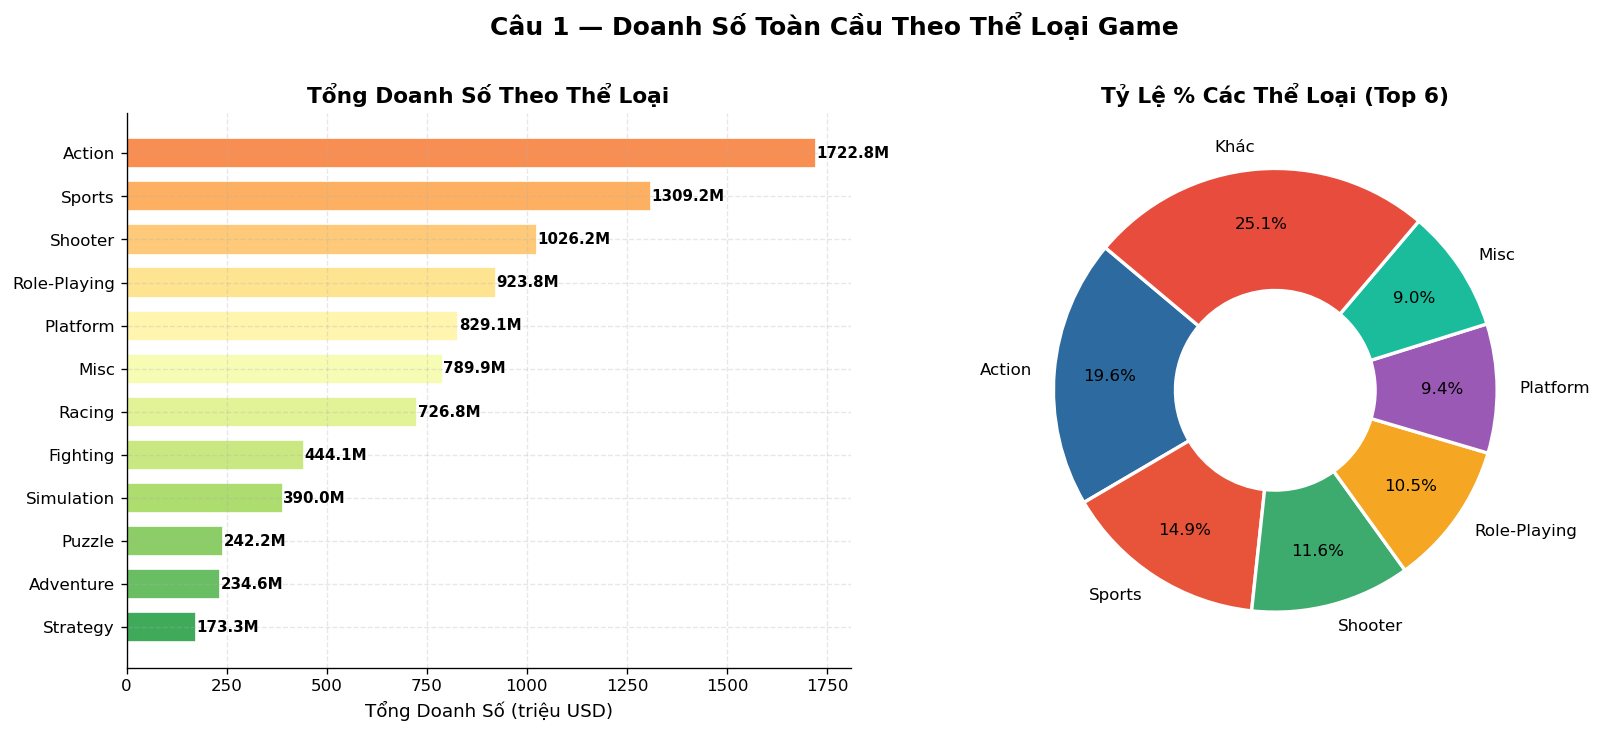

🏆 Thể loại doanh số cao nhất : Action
💰 Doanh số                  : 1722.84 triệu USD
📊 Tổng số thể loại          : 12
💵 Tổng doanh số toàn bộ     : 8811.97 triệu USD


In [17]:

genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

# ================== BẢNG THỐNG KÊ ==================
genre_table = genre_sales.reset_index()
genre_table.columns = ['Thể loại', 'Tổng doanh số (triệu USD)']
genre_table['Tổng doanh số (triệu USD)'] = genre_table['Tổng doanh số (triệu USD)'].round(2)

print("\n================ TỔNG DOANH SỐ THEO THỂ LOẠI ================\n")
print(genre_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Câu 1 — Doanh Số Toàn Cầu Theo Thể Loại Game', fontsize=15, fontweight='bold', y=1.01)

# Horizontal bar
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(genre_sales)))
bars = axes[0].barh(genre_sales.index, genre_sales.values, color=colors, edgecolor='white', height=0.7)
axes[0].invert_yaxis()
axes[0].set_xlabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Tổng Doanh Số Theo Thể Loại', fontsize=13, fontweight='bold')
for bar, val in zip(bars, genre_sales.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9, fontweight='bold')

# Pie chart – top 6
top6 = genre_sales.sort_values(ascending=False).head(6)
other = genre_sales.sort_values(ascending=False).tail(len(genre_sales)-6).sum()
pie_data = pd.concat([top6, pd.Series({'Khác': other})])
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=PALETTE[:len(pie_data)], wedgeprops=wedge_props,
            startangle=140, pctdistance=0.75)
axes[1].set_title('Tỷ Lệ % Các Thể Loại (Top 6)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_q1_genre.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"🏆 Thể loại doanh số cao nhất : {genre_sales.idxmax()}")
print(f"💰 Doanh số                  : {genre_sales.max():.2f} triệu USD")
print(f"📊 Tổng số thể loại          : {len(genre_sales)}")
print(f"💵 Tổng doanh số toàn bộ     : {genre_sales.sum():.2f} triệu USD")

---
## 📊 CÂU HỎI 2 — Hệ máy bán chạy nhất


================ Doanh Số & Số Lượng Game Theo Hệ Máy (TOP 12) ================

Hệ máy  Tổng doanh số (triệu USD)  Số lượng game
   PS2                    1233.46           2127
  X360                     969.60           1234
   PS3                     949.35           1304
   Wii                     909.81           1290
    DS                     818.91           2131
    PS                     727.39           1189
   GBA                     305.62            786
   PSP                     291.71           1197
   PS4                     278.10            336
    PC                     254.70            938
    GB                     254.42             97
    XB                     252.09            803


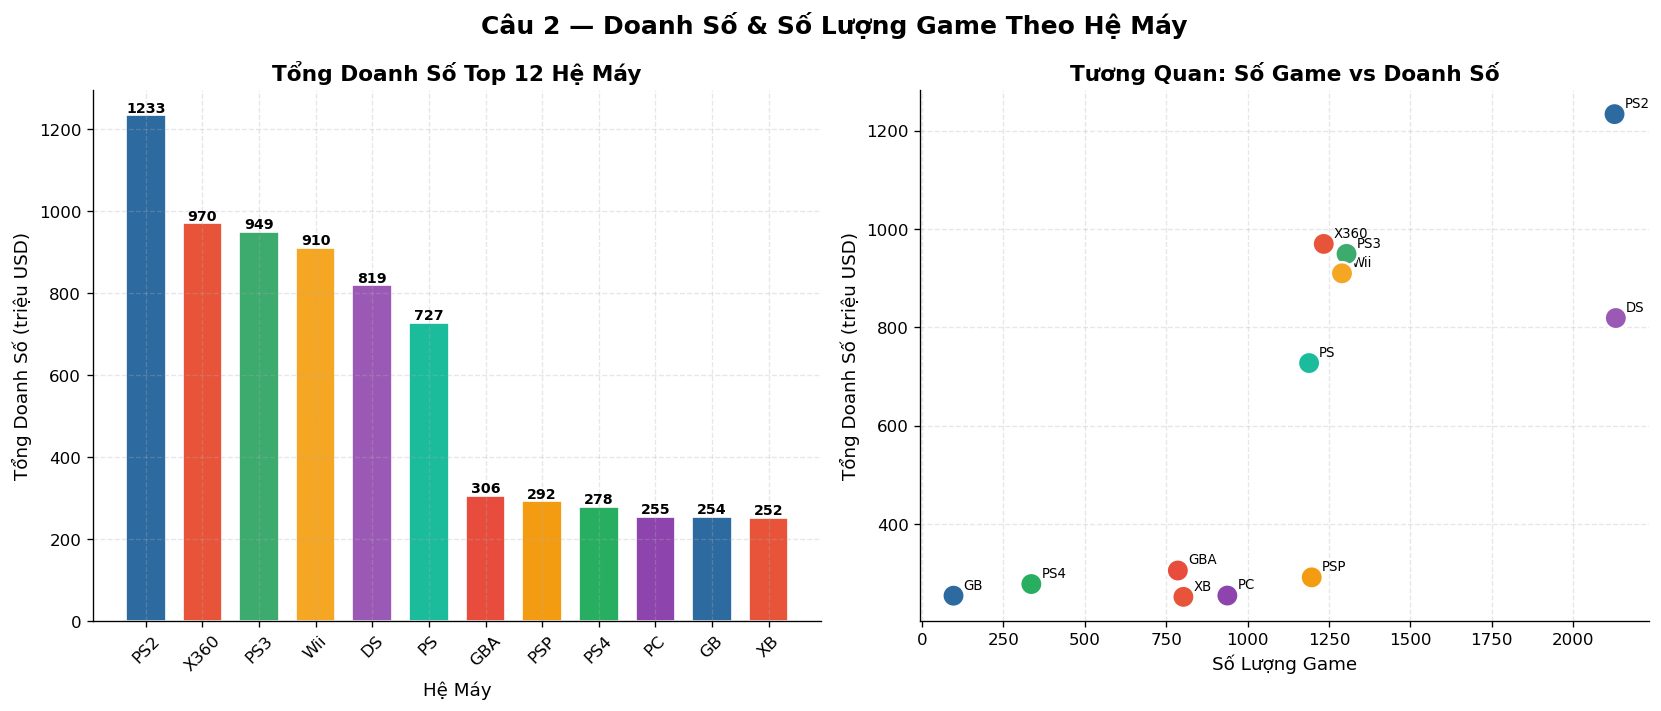


🏆 Hệ máy doanh số cao nhất: PS2 với Doanh số : 1233.46 triệu USD
🎮 Số lượng game            : 2127
📊 Số hệ máy thống kê       : 12
💵 Tổng doanh số Top 12     : 7245.16 triệu USD


In [18]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(12)
platform_count = df.groupby('Platform')['Name'].count().reindex(platform_sales.index)


# ================== BẢNG THỐNG KÊ ==================
platform_table = pd.DataFrame({
    'Hệ máy': platform_sales.index,
    'Tổng doanh số (triệu USD)': platform_sales.values.round(2),
    'Số lượng game': platform_count.values
})

print("\n================ Doanh Số & Số Lượng Game Theo Hệ Máy (TOP 12) ================\n")
print(platform_table.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Câu 2 — Doanh Số & Số Lượng Game Theo Hệ Máy', fontsize=15, fontweight='bold')

# Bar doanh số
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(platform_sales))]
b1 = axes[0].bar(platform_sales.index, platform_sales.values,
                  color=bar_colors, edgecolor='white', width=0.7)
axes[0].set_xlabel('Hệ Máy', fontsize=11)
axes[0].set_ylabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Tổng Doanh Số Top 12 Hệ Máy', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Scatter doanh số vs số game
axes[1].scatter(platform_count.values, platform_sales.values,
                c=bar_colors, s=180, edgecolors='white', linewidth=1.5, zorder=5)
for i, platform in enumerate(platform_sales.index):
    axes[1].annotate(platform,
                     (platform_count[platform], platform_sales[platform]),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('Số Lượng Game', fontsize=11)
axes[1].set_ylabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[1].set_title('Tương Quan: Số Game vs Doanh Số', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_q2_platform.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n🏆 Hệ máy doanh số cao nhất: {platform_sales.idxmax()} với Doanh số : {platform_sales.max():.2f} triệu USD")
print(f"🎮 Số lượng game            : {platform_count[platform_sales.idxmax()]}")
print(f"📊 Số hệ máy thống kê       : {len(platform_sales)}")
print(f"💵 Tổng doanh số Top 12     : {platform_sales.sum():.2f} triệu USD")

---
## 📊 CÂU HỎI 3 — Nhà phát hành doanh số cao nhất


================ Top 10 nhà phát hành theo doanh số ================

               Nhà phát hành  Tổng doanh số  Số lượng game  TB doanh số (Triệu USD)/game
                    Nintendo        1784.43            696                      2.563836
             Electronic Arts        1093.39           1339                      0.816572
                  Activision         721.41            966                      0.746801
 Sony Computer Entertainment         607.28            682                      0.890440
                     Ubisoft         473.54            918                      0.515839
        Take-Two Interactive         399.30            412                      0.969175
                         THQ         340.44            712                      0.478146
Konami Digital Entertainment         278.56            823                      0.338469
                        Sega         270.70            632                      0.428323
          Namco Bandai Games         25

<Figure size 1080x720 with 0 Axes>

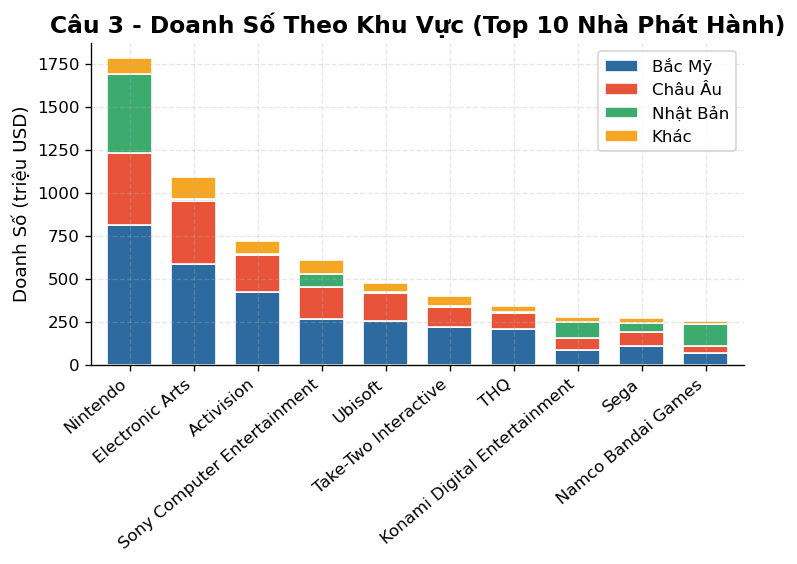

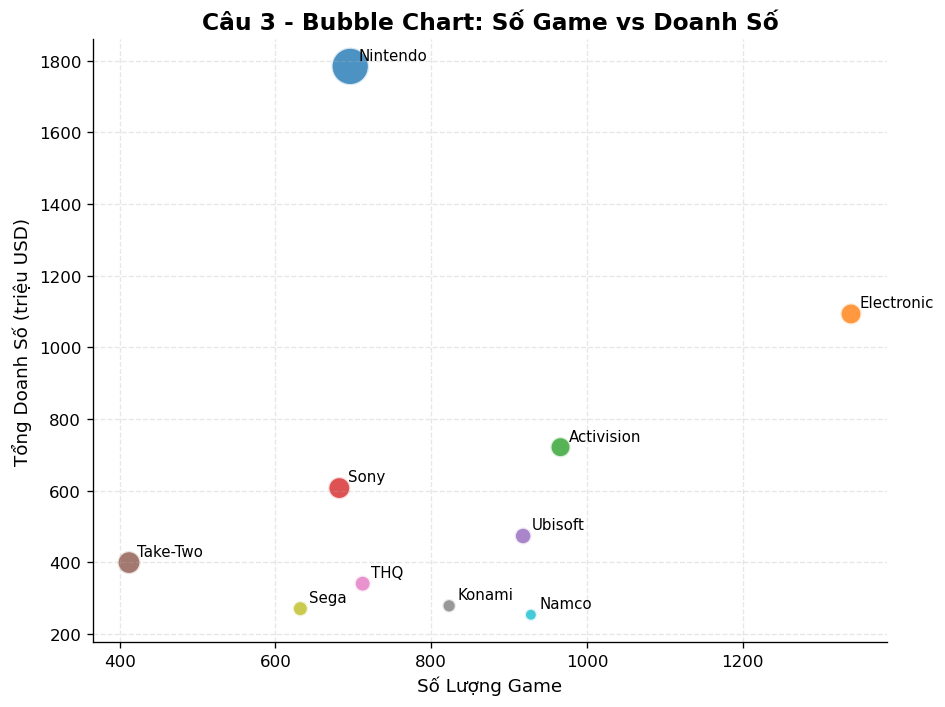


🏆 Nhà phát hành doanh số cao nhất: Nintendo — 1784.43 triệu USD


In [19]:
pub_sales = df.groupby('Publisher').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Num_Games=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean')
).sort_values('Total_Sales', ascending=False).head(10)

print("\n================ Top 10 nhà phát hành theo doanh số ================\n")
print(pub_sales.reset_index().rename(columns={
    'Publisher': 'Nhà phát hành',
    'Total_Sales': 'Tổng doanh số',
    'Num_Games': 'Số lượng game',
    'Avg_Sales': 'TB doanh số (Triệu USD)/game'
}).to_string(index=False))

# =================== Biểu đồ 1: Stacked Bar ===================
pub_region = df[df['Publisher'].isin(pub_sales.index)] \
    .groupby('Publisher')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
pub_region = pub_region.reindex(pub_sales.index)

plt.figure(figsize=(9, 6))
pub_region.plot(
    kind='bar',
    stacked=True,
    color=['#2D6A9F', '#E8543A', '#3DAA6E', '#F5A623'],
    edgecolor='white',
    width=0.7
)

plt.title('Câu 3 - Doanh Số Theo Khu Vực (Top 10 Nhà Phát Hành)',
          fontsize=14, fontweight='bold')
plt.ylabel('Doanh Số (triệu USD)')
plt.xlabel('')
plt.xticks(rotation=40, ha='right')
plt.legend(['Bắc Mỹ', 'Châu Âu', 'Nhật Bản', 'Khác'])

plt.tight_layout()
plt.savefig('chart_q3_stacked_bar.png', dpi=150)
plt.show()


# =================== Biểu đồ 2: Bubble ===================
plt.figure(figsize=(8, 6))

plt.scatter(
    pub_sales['Num_Games'],
    pub_sales['Total_Sales'],
    s=pub_sales['Avg_Sales'] * 200,
    c=range(len(pub_sales)),
    cmap='tab10',
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5
)

for pub, row in pub_sales.iterrows():
    plt.annotate(
        pub.split()[0],
        (row['Num_Games'], row['Total_Sales']),
        textcoords='offset points',
        xytext=(5, 4),
        fontsize=9
    )

plt.title('Câu 3 - Bubble Chart: Số Game vs Doanh Số',
          fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Game')
plt.ylabel('Tổng Doanh Số (triệu USD)')

plt.tight_layout()
plt.savefig('chart_q3_bubble.png', dpi=150)
plt.show()

print(f"\n🏆 Nhà phát hành doanh số cao nhất: {pub_sales['Total_Sales'].idxmax()} — {pub_sales['Total_Sales'].max():.2f} triệu USD")

---
## 📊 CÂU HỎI 4 — Đóng góp của từng khu vực theo thể loại


================ Doanh số theo khu vực và thể loại (Triệu USD) ================

              Bắc Mỹ  Châu Âu  Nhật Bản    Khác
Genre                                          
Action        861.77   516.48    158.65  184.92
Adventure     101.93    63.74     51.99   16.70
Fighting      220.74   100.00     87.15   36.19
Misc          396.92   211.77    106.67   73.92
Platform      445.99   200.65    130.65   51.51
Puzzle        122.01    50.52     56.68   12.47
Racing        356.93   236.31     56.61   76.68
Role-Playing  326.50   187.57    350.29   59.38
Shooter       575.16   310.45     38.18  101.90
Simulation    181.78   113.02     63.54   31.36
Sports        670.09   371.34    134.76  132.65
Strategy       67.83    44.84     49.10   11.23

================ Tỷ lệ đóng góp theo khu vực (%) ================

              Bắc Mỹ  Châu Âu  Nhật Bản  Khác
Genre                                        
Action          50.0     30.0       9.2  10.7
Adventure       43.5     27.2      22.2 

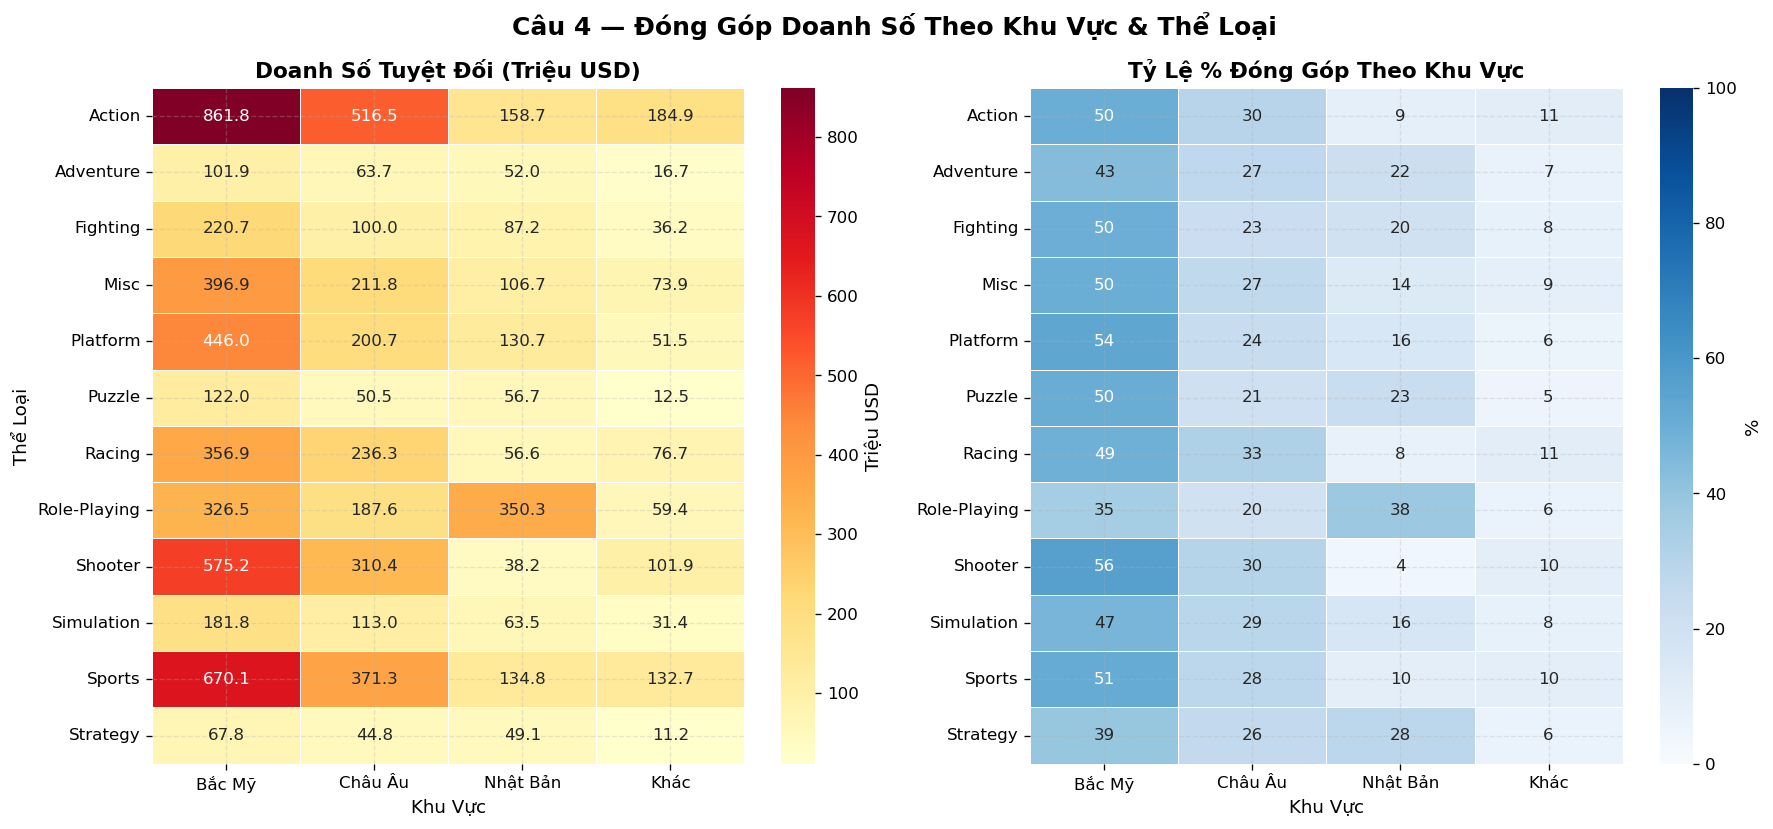

In [20]:
region_genre = df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
region_genre.columns = ['Bắc Mỹ','Châu Âu','Nhật Bản','Khác']
region_genre_pct = region_genre.div(region_genre.sum(axis=1), axis=0) * 100

print("\n================ Doanh số theo khu vực và thể loại (Triệu USD) ================\n")
print(region_genre.round(2).to_string())

print("\n================ Tỷ lệ đóng góp theo khu vực (%) ================\n")
print(region_genre_pct.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Câu 4 — Đóng Góp Doanh Số Theo Khu Vực & Thể Loại', fontsize=15, fontweight='bold')

# Heatmap doanh số tuyệt đối
sns.heatmap(region_genre, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Triệu USD'})
axes[0].set_title('Doanh Số Tuyệt Đối (Triệu USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Khu Vực', fontsize=11)
axes[0].set_ylabel('Thể Loại', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap tỷ lệ %
sns.heatmap(region_genre_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': '%'}, vmin=0, vmax=100)
axes[1].set_title('Tỷ Lệ % Đóng Góp Theo Khu Vực', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khu Vực', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart_q4_region.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📊 CÂU HỎI 5 — Xu hướng doanh số theo thời gian

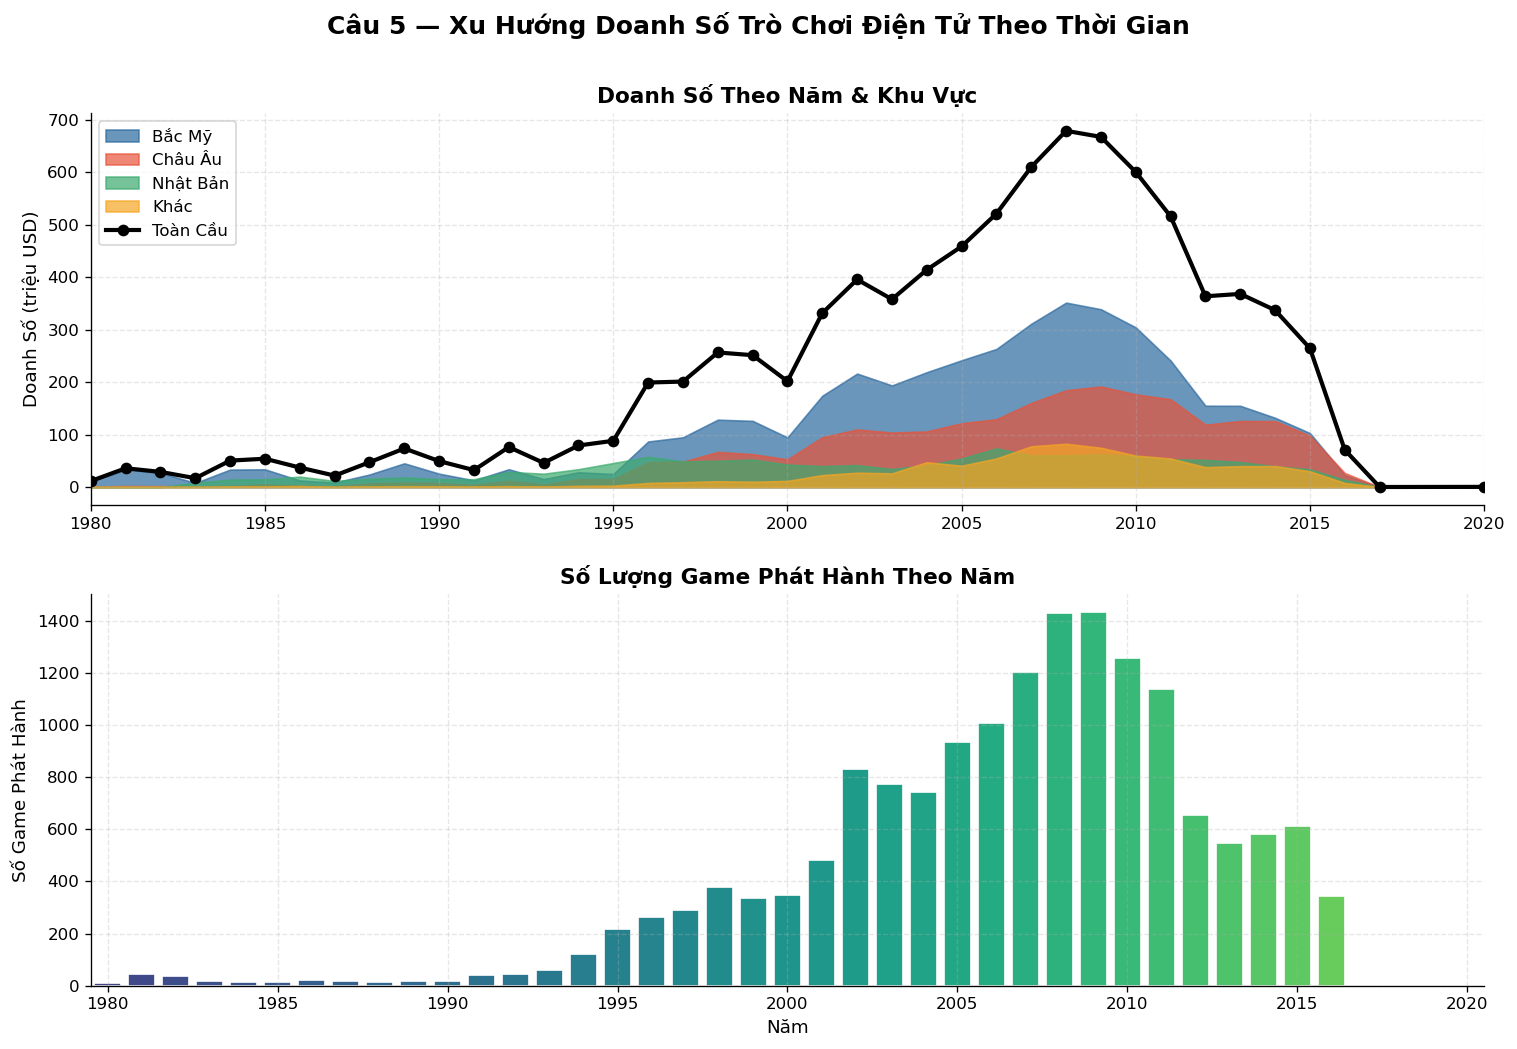

In [21]:
yearly = df.groupby('Year').agg(
    Global=('Global_Sales','sum'),
    NA=('NA_Sales','sum'),
    EU=('EU_Sales','sum'),
    JP=('JP_Sales','sum'),
    Other=('Other_Sales','sum'),
    Count=('Name','count')
).reset_index().sort_values('Year')

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Câu 5 — Xu Hướng Doanh Số Trò Chơi Điện Tử Theo Thời Gian', fontsize=15, fontweight='bold')

# Area chart khu vực
axes[0].fill_between(yearly['Year'], yearly['NA'],  alpha=0.7, color='#2D6A9F', label='Bắc Mỹ')
axes[0].fill_between(yearly['Year'], yearly['EU'],  alpha=0.7, color='#E8543A', label='Châu Âu')
axes[0].fill_between(yearly['Year'], yearly['JP'],  alpha=0.7, color='#3DAA6E', label='Nhật Bản')
axes[0].fill_between(yearly['Year'], yearly['Other'], alpha=0.7, color='#F5A623', label='Khác')
axes[0].plot(yearly['Year'], yearly['Global'], 'k-o', linewidth=2.5, markersize=6,
             zorder=10, label='Toàn Cầu')
axes[0].set_ylabel('Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Doanh Số Theo Năm & Khu Vực', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')
axes[0].set_xlim(yearly['Year'].min(), yearly['Year'].max())

# Bar chart số game phát hành
bar_colors2 = plt.cm.viridis(np.linspace(0.2, 0.8, len(yearly)))
axes[1].bar(yearly['Year'], yearly['Count'], color=bar_colors2, edgecolor='white', width=0.8)
axes[1].set_xlabel('Năm', fontsize=11)
axes[1].set_ylabel('Số Game Phát Hành', fontsize=11)
axes[1].set_title('Số Lượng Game Phát Hành Theo Năm', fontsize=13, fontweight='bold')
axes[1].set_xlim(yearly['Year'].min()-0.5, yearly['Year'].max()+0.5)

plt.tight_layout(pad=2)
plt.savefig('chart_q5_trend.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🤖 MÔ HÌNH 1 — Hồi quy dự đoán doanh số toàn cầu (Regression)

---
## Phân Chia Tập Dữ Liệu (Data Splitting)

### Nhánh Hồi Quy (Regression)
Ma trận đặc trưng **X** gồm các biến độc lập: hệ máy, thể loại, nhà phát hành, doanh số khu vực.  
Biến mục tiêu **Y** là `Global_Sales`.  
Dữ liệu được chia theo tỷ lệ **80% Train / 20% Test** (`random_state=42`).

In [22]:
# ============================================================
# 4.1.2. PHÂN CHIA TẬP DỮ LIỆU — NHÁNH HỒI QUY (Regression)
# ============================================================

df_ml = df[['Genre', 'Platform', 'Publisher', 'Year',
            'Global_Sales']].copy()

df_ml.dropna(inplace=True)

le = LabelEncoder()

for col in ['Genre', 'Platform', 'Publisher']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml[['Genre', 'Platform', 'Publisher', 'Year']]

y = df_ml['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=" * 60)
print("NHÁNH HỒI QUY")
print("=" * 60)
print(f"Tổng mẫu : {len(X)}")
print(f"Số đặc trưng: {X.shape[1]}")

NHÁNH HỒI QUY
Tổng mẫu : 16291
Số đặc trưng: 4


In [23]:
# Huấn luyện các mô hình
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'y_pred': y_pred
    }
    print(f'{name:25s} | R²={results[name]["R²"]:.4f} | RMSE={results[name]["RMSE"]:.4f} | MAE={results[name]["MAE"]:.4f}')

Linear Regression         | R²=0.0034 | RMSE=2.0648 | MAE=0.6117
Random Forest             | R²=0.0276 | RMSE=2.0396 | MAE=0.5405
Gradient Boosting         | R²=0.0725 | RMSE=1.9920 | MAE=0.5405


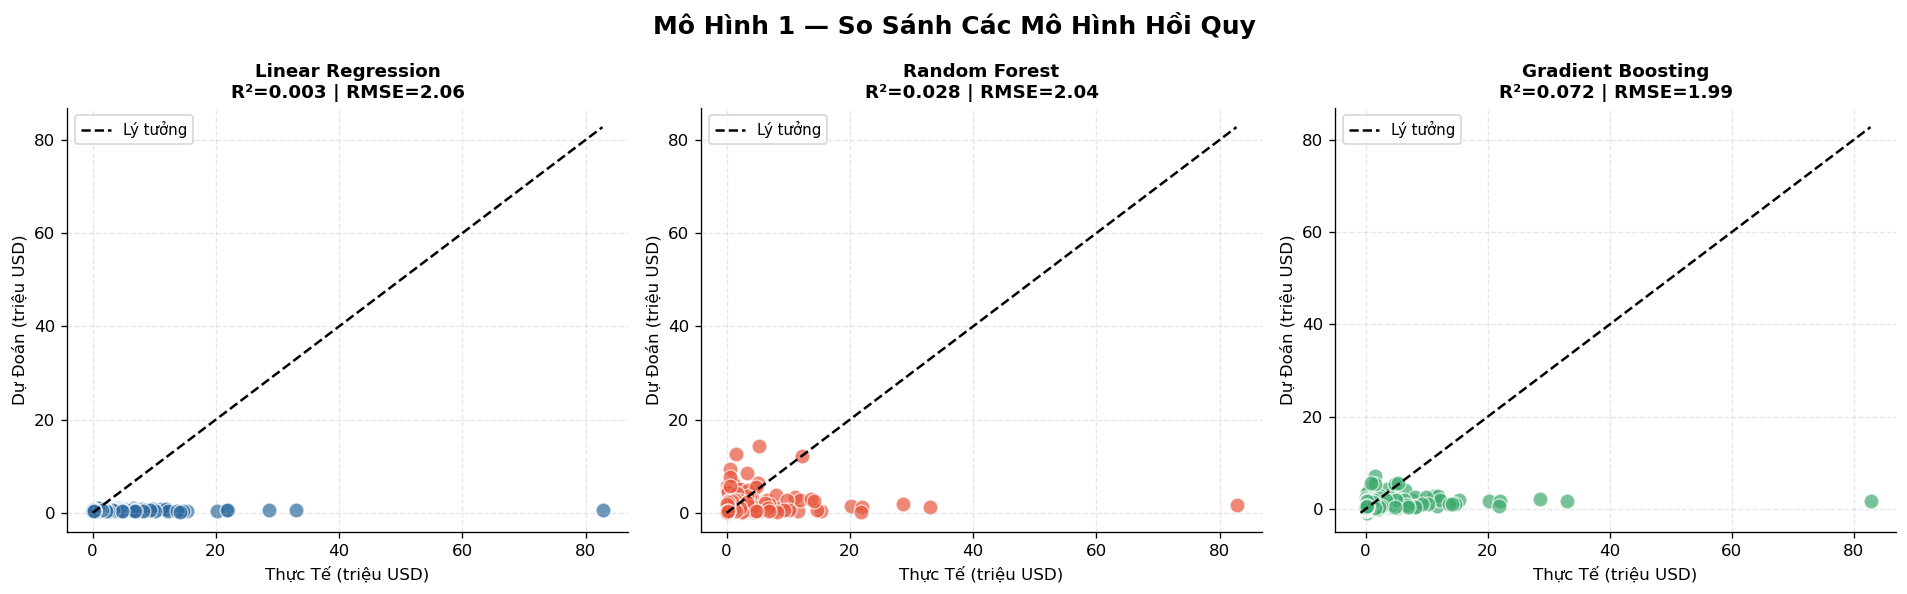

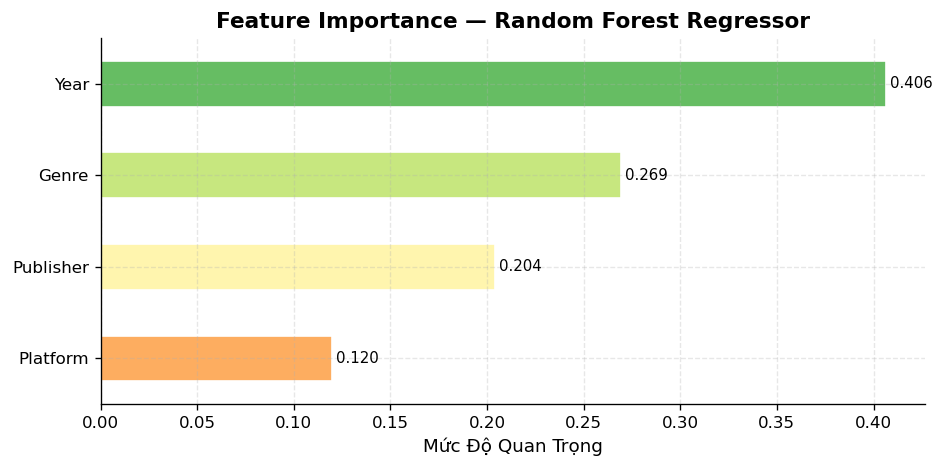

In [24]:
# Trực quan hóa kết quả hồi quy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mô Hình 1 — So Sánh Các Mô Hình Hồi Quy', fontsize=15, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, res['y_pred'], alpha=0.7,
               color=PALETTE[i], edgecolors='white', linewidth=0.8, s=80)
    min_v = min(y_test.min(), res['y_pred'].min())
    max_v = max(y_test.max(), res['y_pred'].max())
    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1.5, label='Lý tưởng')
    ax.set_xlabel('Thực Tế (triệu USD)', fontsize=10)
    ax.set_ylabel('Dự Đoán (triệu USD)', fontsize=10)
    ax.set_title(f'{name}\nR²={res["R²"]:.3f} | RMSE={res["RMSE"]:.2f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart_regression.png', bbox_inches='tight', dpi=150)
plt.show()

# Feature Importance (Random Forest)
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Mức Độ Quan Trọng', fontsize=11)
for bar, val in zip(ax.patches, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔵 MÔ HÌNH 2 — Phân cụm game theo đặc điểm doanh số (K-Means Clustering)

## Phân Chia Tập Dữ Liệu (Data Splitting)
### 🔵 Nhánh Phân Cụm (Clustering)
Toàn bộ thuộc tính định lượng về doanh số được chuẩn hóa qua **StandardScaler**  
→ đưa về phân phối chuẩn với **Mean = 0** và **Std = 1**, loại bỏ lệch pha thang đo giữa các thị trường.

  NHÁNH PHÂN CỤM — Clustering Branch
  Số mẫu phân cụm  : 16,291
  Số đặc trưng     : 5



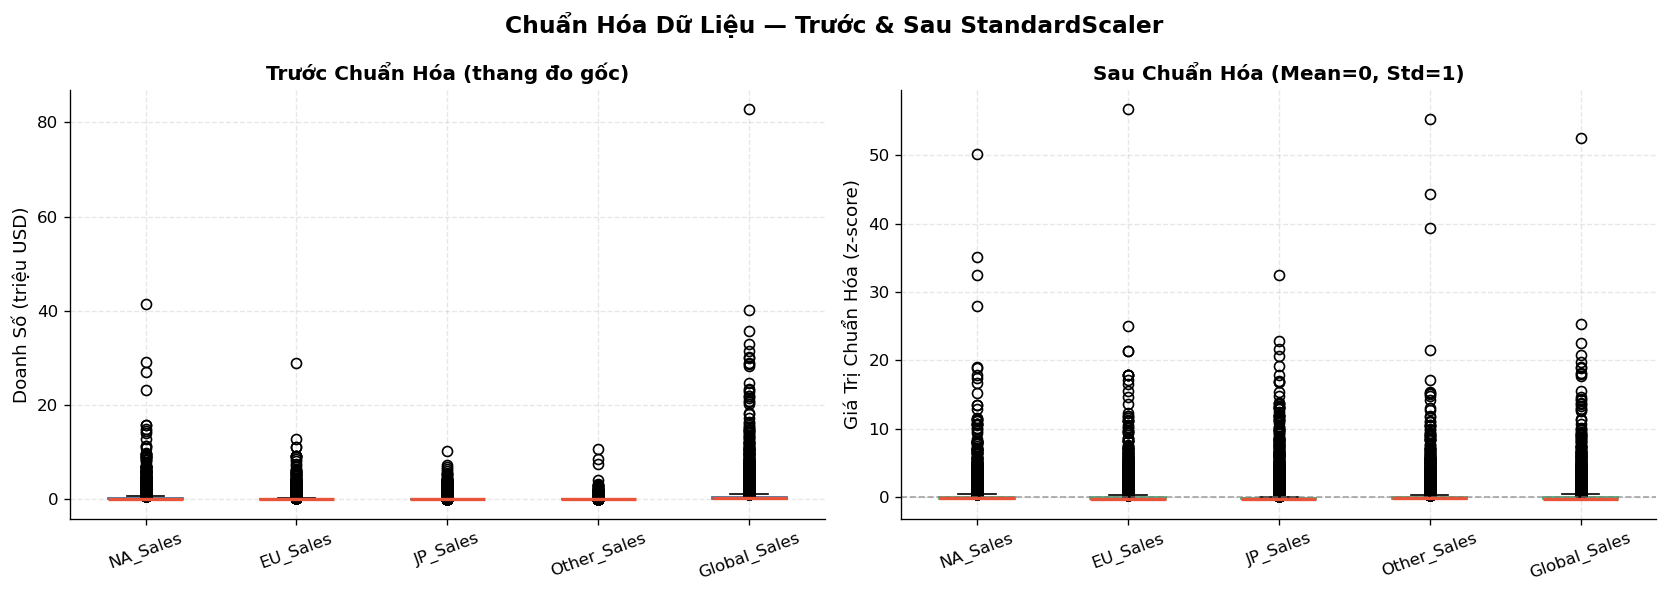


✅ Chuẩn hóa StandardScaler hoàn tất!


In [25]:
# ============================================================
# 4.1.2. PHÂN CHIA TẬP DỮ LIỆU — NHÁNH PHÂN CỤM (Clustering)
# ============================================================

features_cluster = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
df_cluster = df[features_cluster].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

stats_before = df_cluster.agg(['mean', 'std']).round(4)
stats_after  = pd.DataFrame(X_scaled, columns=features_cluster).agg(['mean', 'std']).round(4)

print("=" * 60)
print("  NHÁNH PHÂN CỤM — Clustering Branch")
print("=" * 60)
print(f"  Số mẫu phân cụm  : {len(df_cluster):,}")
print(f"  Số đặc trưng     : {len(features_cluster)}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chuẩn Hóa Dữ Liệu — Trước & Sau StandardScaler', fontsize=14, fontweight='bold')

df_cluster.boxplot(ax=axes[0], patch_artist=True,
                   boxprops=dict(facecolor='#AED6F1', color='#2D6A9F'),
                   medianprops=dict(color='#E8543A', linewidth=2))
axes[0].set_title('Trước Chuẩn Hóa (thang đo gốc)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Doanh Số (triệu USD)')
axes[0].tick_params(axis='x', rotation=20)

pd.DataFrame(X_scaled, columns=features_cluster).boxplot(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='#A9DFBF', color='#3DAA6E'),
    medianprops=dict(color='#E8543A', linewidth=2))
axes[1].set_title('Sau Chuẩn Hóa (Mean=0, Std=1)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Giá Trị Chuẩn Hóa (z-score)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig('chart_scaling.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Chuẩn hóa StandardScaler hoàn tất!")

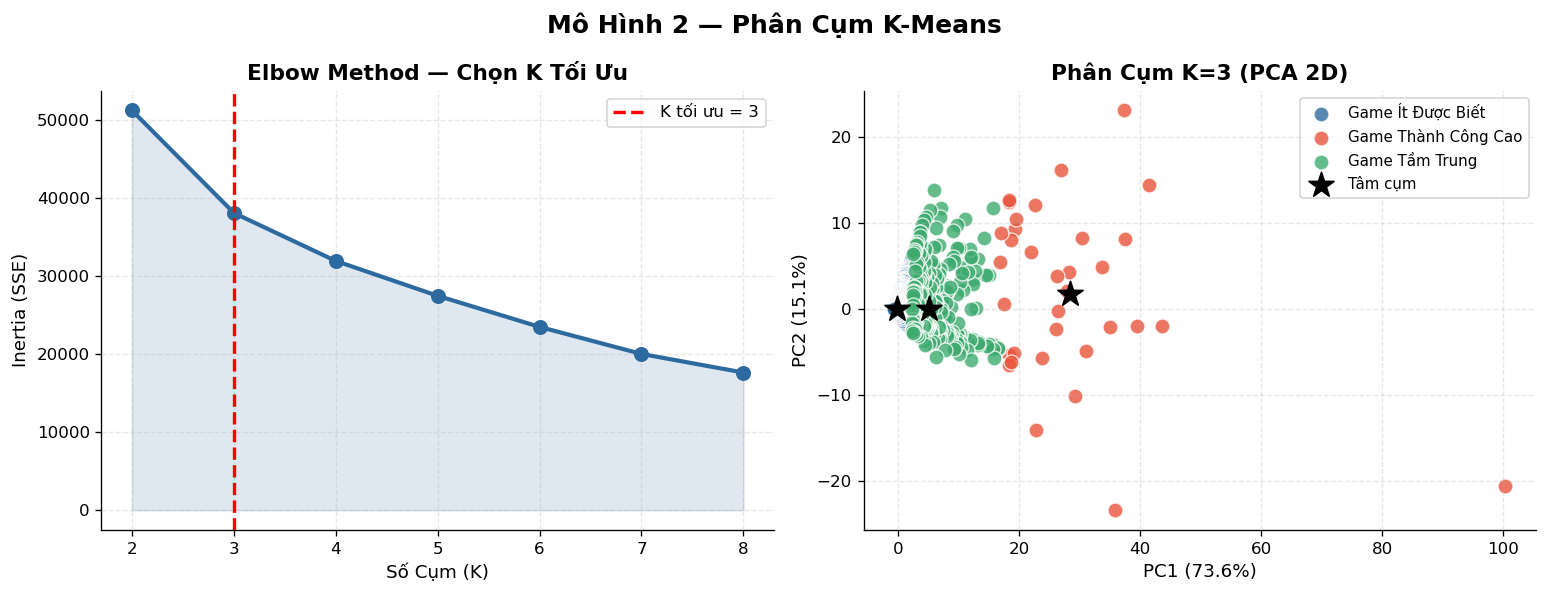


📊 Thống kê theo cụm:
         NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
Cluster                                                         
0            0.17      0.09      0.05         0.03          0.34
1           11.47      6.55      3.46         2.26         23.73
2            2.11      1.45      0.59         0.47          4.61


In [26]:
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mô Hình 2 — Phân Cụm K-Means', fontsize=15, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8, color='#2D6A9F')
axes[0].fill_between(K_range, inertias, alpha=0.15, color='#2D6A9F')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='K tối ưu = 3')
axes[0].set_xlabel('Số Cụm (K)', fontsize=11)
axes[0].set_ylabel('Inertia (SSE)', fontsize=11)
axes[0].set_title('Elbow Method — Chọn K Tối Ưu', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# K=3 clustering với PCA 2D
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_colors = ['#2D6A9F', '#E8543A', '#3DAA6E']

# Đặt tên cụm theo Global Sales trung bình
temp = df_cluster.copy()
temp["Cluster"] = labels

cluster_order = (
    temp.groupby("Cluster")["Global_Sales"]
        .mean()
        .sort_values()
        .index.tolist()
)

cluster_names = {}
cluster_names[cluster_order[0]] = "Game Ít Được Biết"
cluster_names[cluster_order[1]] = "Game Tầm Trung"
cluster_names[cluster_order[2]] = "Game Thành Công Cao"
for i in range(3):
    mask = labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[i], s=80, alpha=0.8,
                    edgecolors='white', linewidth=0.8, label=cluster_names[i])

# Tâm cụm
centers_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centers_pca[:,0], centers_pca[:,1], c='black',
                s=250, marker='*', zorder=10, label='Tâm cụm')

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Phân Cụm K=3 (PCA 2D)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

# Thêm nhãn cụm vào df
df_cluster = df[features_cluster].dropna().copy()
df_cluster['Cluster'] = labels
print('\n📊 Thống kê theo cụm:')
print(df_cluster.groupby('Cluster')[features_cluster].mean().round(2))

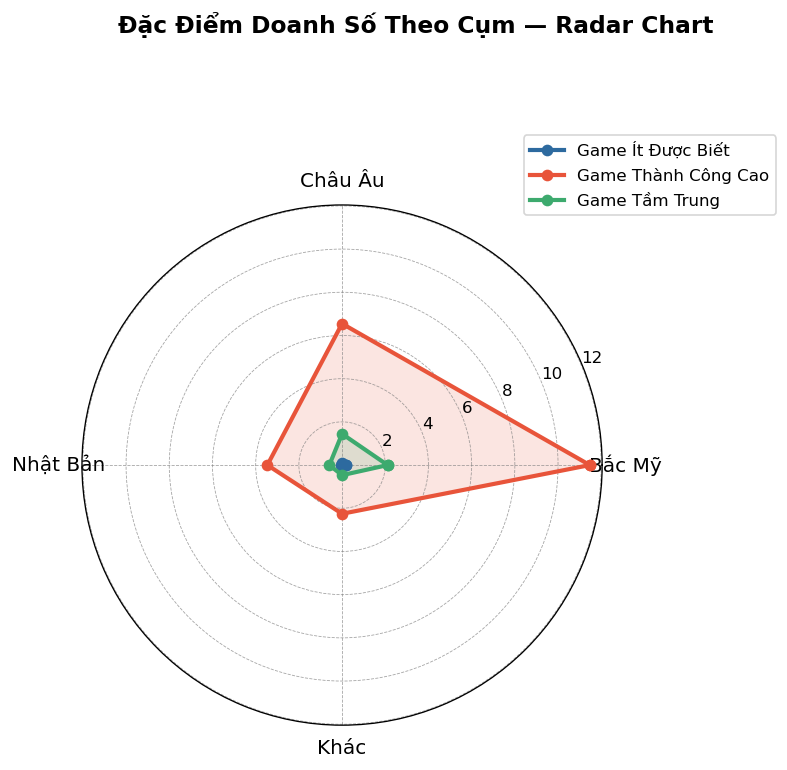

In [27]:
# Radar chart đặc điểm từng cụm
cluster_means = df_cluster.groupby('Cluster')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].mean()

categories = ['Bắc Mỹ', 'Châu Âu', 'Nhật Bản', 'Khác']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Đặc Điểm Doanh Số Theo Cụm — Radar Chart', fontsize=14, fontweight='bold')

for i, (cid, row) in enumerate(cluster_means.iterrows()):
    vals = row.values.tolist()
    vals += vals[:1]

    ax.plot(
        angles,
        vals,
        'o-',
        linewidth=2.5,
        color=cluster_colors[cid],
        label=cluster_names[cid]
    )

    ax.fill(
        angles,
        vals,
        alpha=0.15,
        color=cluster_colors[cid]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('chart_radar.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📋 KẾT LUẬN & ĐÁNH GIÁ

In [28]:
print('='*65)
print('  TỔNG KẾT KẾT QUẢ PHÂN TÍCH')
print('='*65)
print()
print('📊 PHÂN TÍCH DỮ LIỆU:')
print(f'  • Thể loại doanh số cao nhất : {df.groupby("Genre")["Global_Sales"].sum().idxmax()}')
print(f'  • Hệ máy doanh số cao nhất   : {df.groupby("Platform")["Global_Sales"].sum().idxmax()}')
print(f'  • Nhà phát hành dẫn đầu      : {df.groupby("Publisher")["Global_Sales"].sum().idxmax()}')
top_region = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
reg_names = {'NA_Sales':'Bắc Mỹ','EU_Sales':'Châu Âu','JP_Sales':'Nhật Bản','Other_Sales':'Khác'}
print(f'  • Khu vực đóng góp cao nhất  : {reg_names[top_region.idxmax()]} ({top_region.max():.1f}M USD)')
print()
print('🤖 MÔ HÌNH DỰ ĐOÁN (REGRESSION):')
best_model = max(results, key=lambda k: results[k]['R²'])
for name, res in results.items():
    mark = '✅' if name == best_model else '  '
    print(f'  {mark} {name:25s}: R²={res["R²"]:.4f} | RMSE={res["RMSE"]:.4f}')
print(f'  → Mô hình tốt nhất: {best_model}')
print()
print('🔵 PHÂN CỤM (K-MEANS, K=3):')
for i in range(3):
    n = (df_cluster['Cluster'] == i).sum()
    avg = df_cluster[df_cluster['Cluster']==i]['Global_Sales'].mean()
    print(f'  • Cụm {i} — {cluster_names[i]:25s}: {n} game | TB {avg:.2f}M USD')
print()
print('='*65)

  TỔNG KẾT KẾT QUẢ PHÂN TÍCH

📊 PHÂN TÍCH DỮ LIỆU:
  • Thể loại doanh số cao nhất : Action
  • Hệ máy doanh số cao nhất   : PS2
  • Nhà phát hành dẫn đầu      : Nintendo
  • Khu vực đóng góp cao nhất  : Bắc Mỹ (4327.7M USD)

🤖 MÔ HÌNH DỰ ĐOÁN (REGRESSION):
     Linear Regression        : R²=0.0034 | RMSE=2.0648
     Random Forest            : R²=0.0276 | RMSE=2.0396
  ✅ Gradient Boosting        : R²=0.0725 | RMSE=1.9920
  → Mô hình tốt nhất: Gradient Boosting

🔵 PHÂN CỤM (K-MEANS, K=3):
  • Cụm 0 — Game Ít Được Biết        : 15687 game | TB 0.34M USD
  • Cụm 1 — Game Thành Công Cao      : 34 game | TB 23.73M USD
  • Cụm 2 — Game Tầm Trung           : 570 game | TB 4.61M USD

